**The objective of this project is to analyze superstore sales using EDA and find out the factors affecting sales.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**1. LOADING DATA**

In [ ]:
df = pd.read_csv("superstore_final_dataset (1).csv", encoding='latin1')

In [ ]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row_ID,Postal_Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [ ]:
df.isnull().sum()

,0
Row_ID,0
Order_ID,0
Order_Date,0
Ship_Date,0
Ship_Mode,0
Customer_ID,0
Customer_Name,0
Segment,0
Country,0
City,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

NO DUPLICATE DATA

In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

In [ ]:
#YEAR
df['Year'] = df['Order_Date'].dt.year
#MONTH
df['Month'] = df['Order_Date'].dt.month
#MONTH NAME
df['Month_Name'] = df['Order_Date'].dt.month_name()

In [ ]:
print(df.shape)
print(df.columns)
df.head()

(9789, 21)
Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales', 'Year', 'Month', 'Month_Name'],
      dtype='object')


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Year,Month,Month_Name
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680,2016,10,October


In [ ]:
print(df.columns.tolist())

['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales', 'Year', 'Month', 'Month_Name']


*2. CREATING THE KPI's*

In [ ]:
total_revenue = df['Sales'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 2252607.4127


In [ ]:
total_orders = df['Order_ID'].nunique()

print("Total Orders:", total_orders)

Total Orders: 4916


In [ ]:
total_customers = df['Customer_ID'].nunique()

print("Total Customers:", total_customers)

Total Customers: 793


In [ ]:
aov = total_revenue / total_orders

print("Average Order Value:", round(aov, 2))

Average Order Value: 458.22


*3. monthly sales trend*

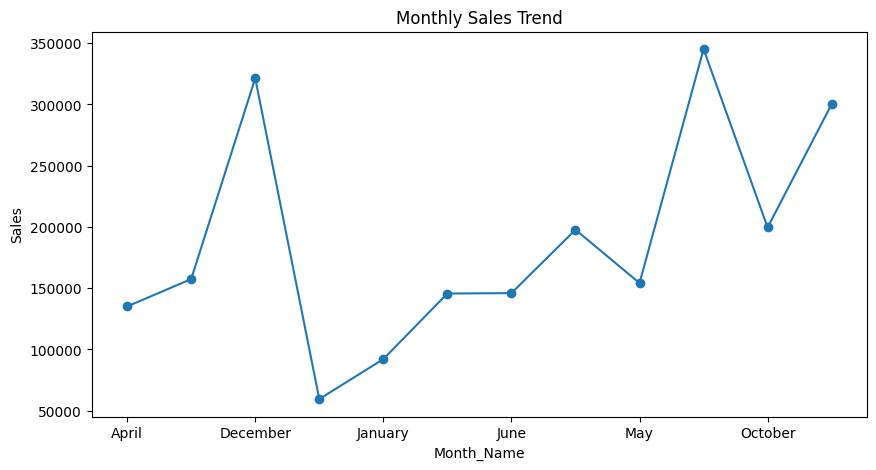

In [ ]:
monthly_sales = df.groupby('Month_Name')['Sales'].sum()

monthly_sales.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

*4.regionol analysis*

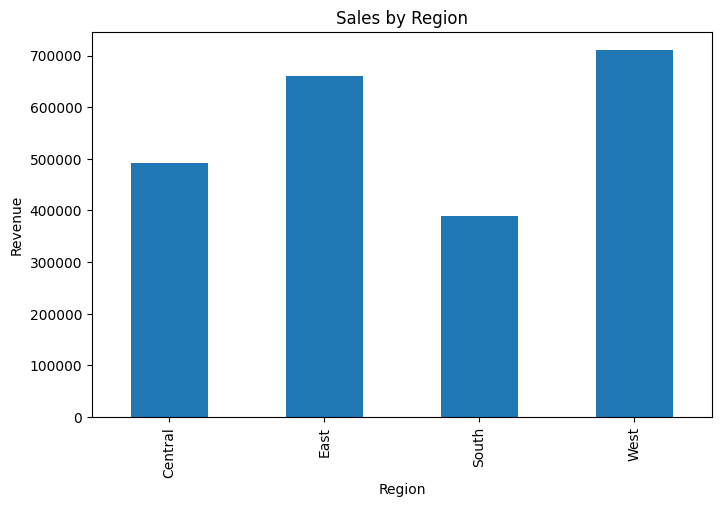

In [ ]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Sales by Region")
plt.ylabel("Revenue")
plt.show()

*5. catogory analysis*

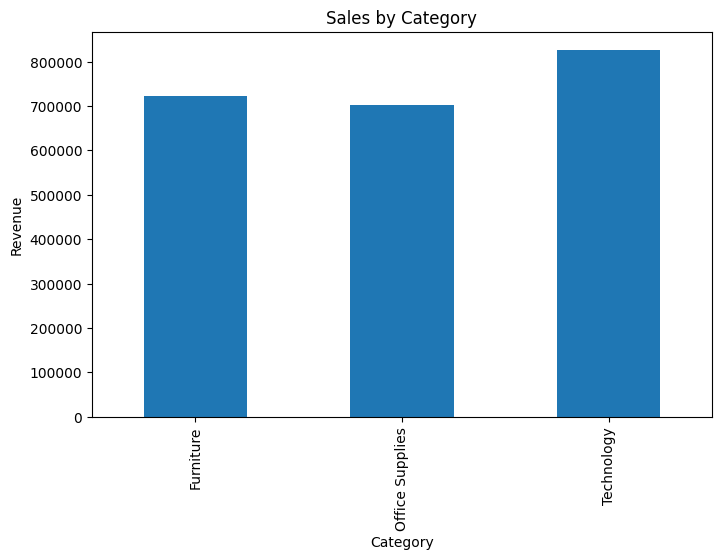

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Sales by Category")
plt.ylabel("Revenue")
plt.show()

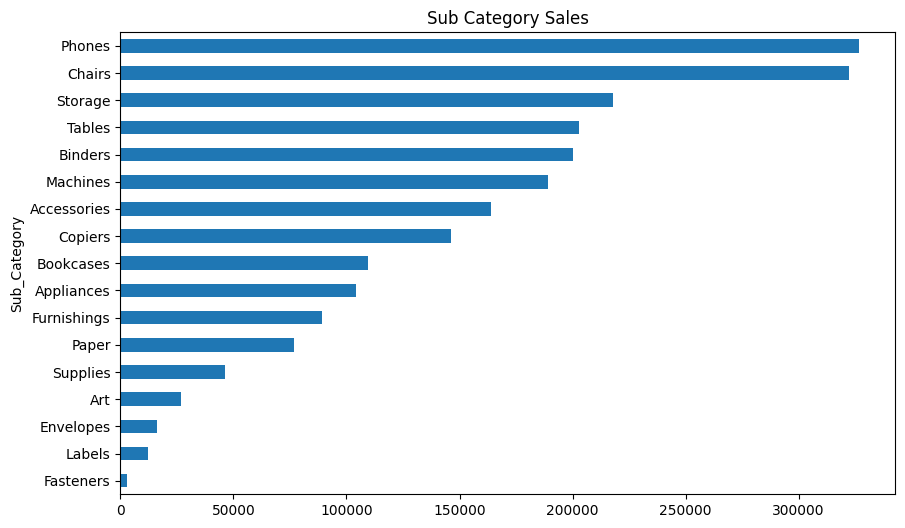

In [ ]:
subcategory_sales = df.groupby(
    'Sub_Category'
)['Sales'].sum()

subcategory_sales.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Sub Category Sales")
plt.show()

***6. top 10 products and its visualization***

In [ ]:
top_products = df.groupby(
    'Product_Name'
)['Sales'].sum()

top10 = top_products.sort_values(
    ascending=False
).head(10)

print(top10)

Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


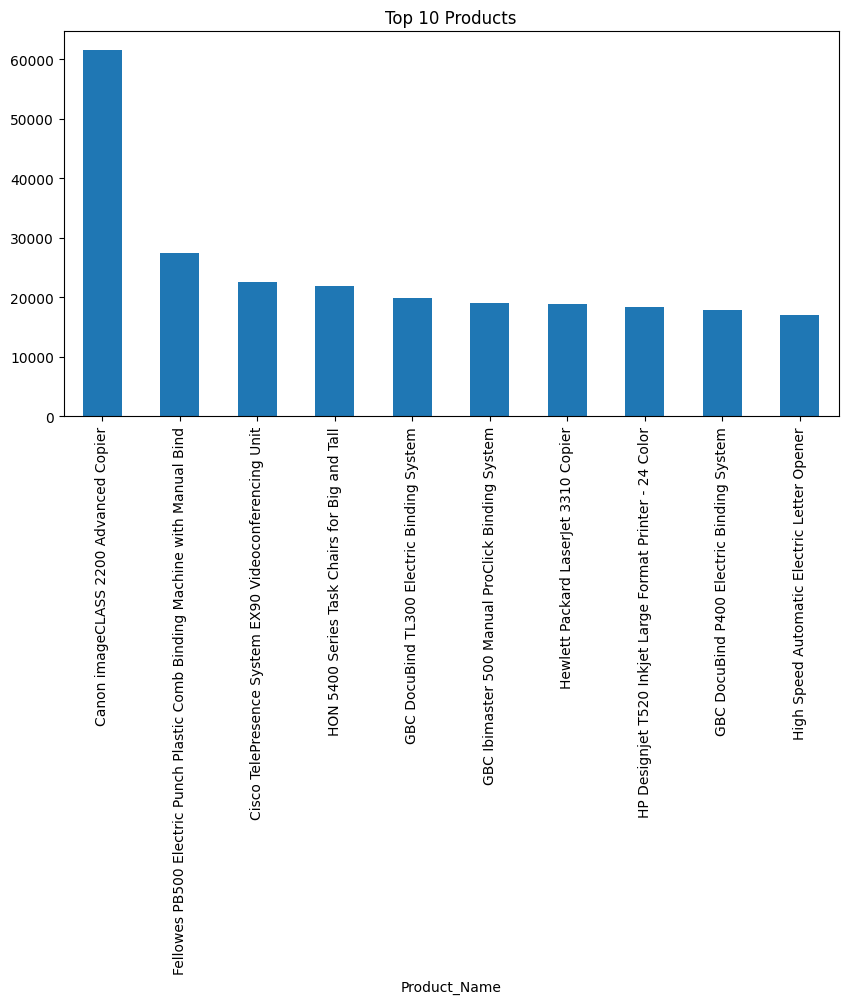

In [ ]:
top10.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Products")
plt.show()

In [ ]:
bottom10 = df.groupby(
    'Product_Name'
)['Sales'].sum().sort_values().head(10)

print(bottom10)

Product_Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Acme Serrated Blade Letter Opener                                   7.632
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink     7.800
Xerox 1989                                                          7.968
Stockwell Gold Paper Clips                                          8.096
Acco Economy Flexible Poly Round Ring Binder                        8.352
Name: Sales, dtype: float64


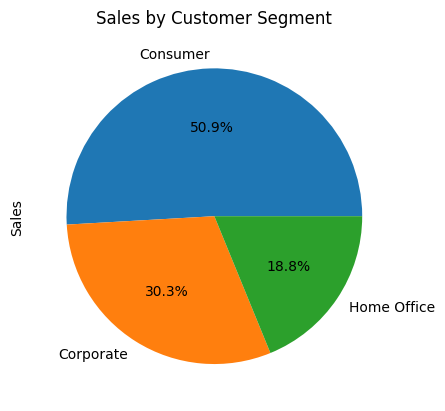

In [ ]:
segment_sales = df.groupby(
    'Segment'
)['Sales'].sum()

segment_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Sales by Customer Segment")
plt.show()

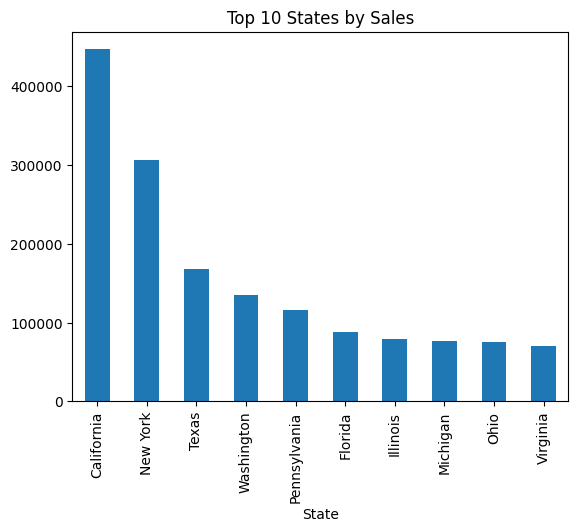

In [ ]:
state_sales = df.groupby(
    'State'
)['Sales'].sum().sort_values(
    ascending=False
).head(10)

state_sales.plot(
    kind='bar'
)

plt.title("Top 10 States by Sales")
plt.show()

**MAJOR FINDINGS**


1.The sales is highly positively skewed indicating, sales from most of the customers are low to medium. While sales from very few number of customers are very high.

2.Greater than one third (75%) of the customer's sales are between 0-210.

3.This indicated low value/high volume and high value/low volume purchase.

4.In shipping mode, standard one is most preferred as it is economical and also contribute to highest in sales.

5.Majority of customers are consumers, and rest are corporate and home office. They contribute to total revenue based on their distribution.

6.Top cities/states has dominance in in sales order, due to their population and accessibility.

**RECOMMENDATIONS**

1.Increase inventory of top-selling products.

2.Run promotions in low-performing regions.

3.Create targeted campaigns for high-value customer segments.

4.Promote low-selling products through bundles.
Increase marketing before peak sales months

**CONCLUSION**

The sales performance analysis identified top-performing regions, categories, and products. Seasonal sales patterns were observed, and profitability analysis revealed opportunities to improve margins. Strategic recommendations were proposed to increase revenue and overall business performance.